<a href="https://colab.research.google.com/github/DipenKumarDasDhrubo/Data_Mining_Lab/blob/main/IBCF_Recommendation_System_0432220005101063.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 Item-Based Collaborative Filtering — Movie Recommendation System
**Course:** Data Mining and Warehouse Lab &nbsp;|&nbsp; **Type:** Individual Assignment



## 📦 Section 1 — Import Libraries

In [1]:
# Standard data-science libraries — all available on Google Colab by default
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity   # item-item similarity
from sklearn.model_selection import train_test_split     # evaluation split
from sklearn.metrics import mean_squared_error           # RMSE helper

import ipywidgets as widgets                             # interactive UI
from IPython.display import display, HTML, clear_output
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
%matplotlib inline
print("✅ Libraries loaded.")


✅ Libraries loaded.


## 📂 Section 2 — Load & Explore Dataset

In [2]:
# ── Mount Google Drive and load the two CSV files ─────────────────────────────
# Place movies.csv and ratings.csv inside:  MyDrive/DM_LAB/
from google.colab import drive
drive.mount('/content/drive')

MOVIES_PATH  = '/content/drive/MyDrive/8th semester/Data_Mining_Lab/Recommendation_system/movies.csv'
RATINGS_PATH = '/content/drive/MyDrive/8th semester/Data_Mining_Lab/Recommendation_system/ratings.csv'

movies  = pd.read_csv(MOVIES_PATH)
ratings = pd.read_csv(RATINGS_PATH)

print("── Dataset Overview ─────────────────────────────────────")
print(f"  Movies  : {movies.shape[0]:,} rows  |  Columns: {list(movies.columns)}")
print(f"  Ratings : {ratings.shape[0]:,} rows  |  Columns: {list(ratings.columns)}")
print(f"  Users   : {ratings['userId'].nunique():,}  unique")
print(f"  Movies rated: {ratings['movieId'].nunique():,}  unique")
print(f"  Rating range: {ratings['rating'].min()} – {ratings['rating'].max()}")
print()
print("── Sample: movies ───────────────────────────────────────")
display(movies.head(5))
print("── Sample: ratings ──────────────────────────────────────")
display(ratings.head(5))


Mounted at /content/drive
── Dataset Overview ─────────────────────────────────────
  Movies  : 9,742 rows  |  Columns: ['movieId', 'title', 'genres']
  Ratings : 100,836 rows  |  Columns: ['userId', 'movieId', 'rating', 'timestamp']
  Users   : 610  unique
  Movies rated: 9,724  unique
  Rating range: 0.5 – 5.0

── Sample: movies ───────────────────────────────────────


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


── Sample: ratings ──────────────────────────────────────


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


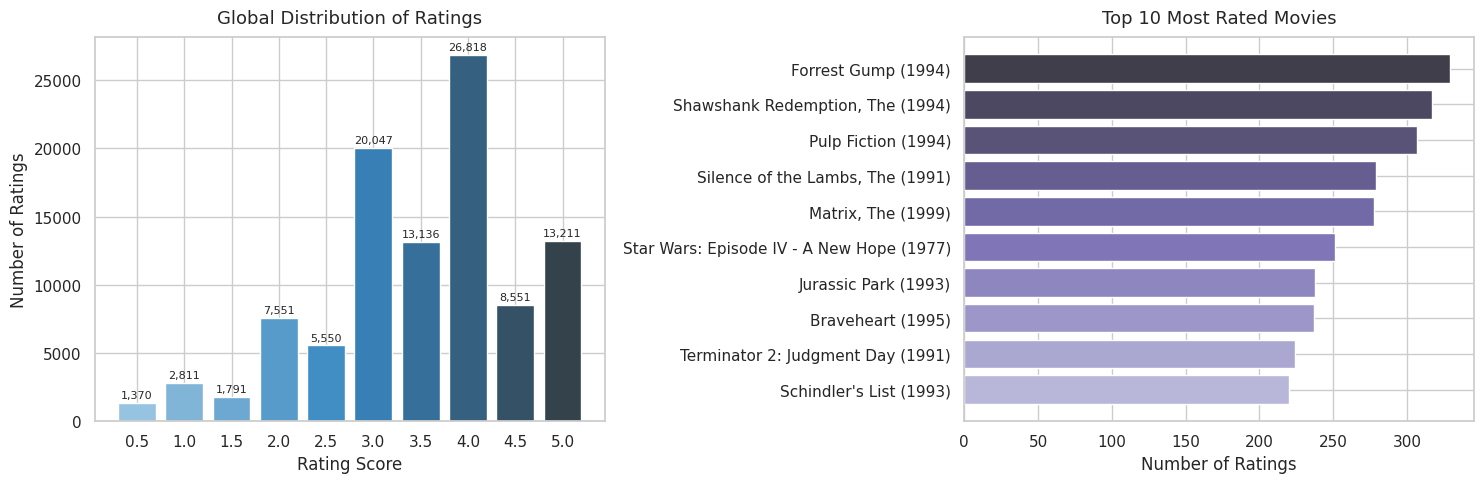

EDA charts saved.


In [3]:
# ── Exploratory visualisations ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1 — distribution of ratings across the whole dataset
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(str), rating_counts.values,
            color=sns.color_palette('Blues_d', len(rating_counts)))
axes[0].set_title('Global Distribution of Ratings', fontsize=13, pad=10)
axes[0].set_xlabel('Rating Score')
axes[0].set_ylabel('Number of Ratings')
for bar, val in zip(axes[0].patches, rating_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=8)

# Plot 2 — top-10 most-rated movies (by number of ratings, not average score)
merged_temp = ratings.merge(movies[['movieId','title']], on='movieId')
top10 = merged_temp.groupby('title')['rating'].count().nlargest(10)
axes[1].barh(top10.index[::-1], top10.values[::-1],
             color=sns.color_palette('Purples_d', 10))
axes[1].set_title('Top 10 Most Rated Movies', fontsize=13, pad=10)
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=130, bbox_inches='tight')
plt.show()
print("EDA charts saved.")


## 🧹 Section 3 — Data Preprocessing

In [4]:
# ── Step 1: drop the timestamp column (not needed for CF) ─────────────────────
ratings = ratings.drop(columns=['timestamp'], errors='ignore')

# ── Step 2: remove duplicate (userId, movieId) pairs — keep the latest rating ─
before = len(ratings)
ratings = ratings.drop_duplicates(subset=['userId','movieId'], keep='last')
print(f"Removed {before - len(ratings)} duplicate entries.")

# ── Step 3: keep only active users and popular movies ─────────────────────────
# Filtering reduces extreme sparsity and makes cosine similarity more reliable.
MIN_USER_RATINGS  = 20   # user must have rated at least 20 movies
MIN_MOVIE_RATINGS = 15   # movie must have been rated by at least 15 users

movie_pop  = ratings.groupby('movieId')['rating'].count()
user_activ = ratings.groupby('userId')['rating'].count()

ratings_filtered = ratings[
    ratings['movieId'].isin(movie_pop[movie_pop >= MIN_MOVIE_RATINGS].index) &
    ratings['userId'].isin(user_activ[user_activ >= MIN_USER_RATINGS].index)
].copy()

print(f"After filtering:")
print(f"  Ratings : {len(ratings_filtered):,}")
print(f"  Users   : {ratings_filtered['userId'].nunique():,}")
print(f"  Movies  : {ratings_filtered['movieId'].nunique():,}")

sparsity = 1 - len(ratings_filtered) / (
    ratings_filtered['userId'].nunique() * ratings_filtered['movieId'].nunique()
)
print(f"  Matrix sparsity: {sparsity*100:.1f}%")


Removed 0 duplicate entries.
After filtering:
  Ratings : 73,845
  Users   : 610
  Movies  : 1,650
  Matrix sparsity: 92.7%


## 🧮 Section 4 — Build User-Item Interaction Matrix


In [5]:
# Pivot ratings into a user-item matrix (rows=users, columns=movies)
user_item_matrix = ratings_filtered.pivot(
    index='userId', columns='movieId', values='rating'
)

print(f"User-Item matrix shape: {user_item_matrix.shape}")
print(f"  → {user_item_matrix.shape[0]} users  ×  {user_item_matrix.shape[1]} movies")
print()
print("Sample (top-left 6×6 slice):")
display(user_item_matrix.iloc[:6, :6].round(1))


User-Item matrix shape: (610, 1650)
  → 610 users  ×  1650 movies

Sample (top-left 6×6 slice):


movieId,1,2,3,5,6,7
userId,,,,,,
1,4.0,NaN,4.0,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,5.0,4.0,4.0


## 🔢 Section 5 — Compute Item-Item Cosine Similarity


In [6]:
# Fill NaN with 0 for the cosine computation only
matrix_filled = user_item_matrix.fillna(0)

# cosine_similarity expects rows = items, so we transpose
item_sim_values = cosine_similarity(matrix_filled.T)

# Label rows and columns with movieId for convenient indexing
item_sim_df = pd.DataFrame(
    item_sim_values,
    index   = user_item_matrix.columns,
    columns = user_item_matrix.columns
)

print(f"Item-similarity matrix shape: {item_sim_df.shape}")
print()
print("Sample values (first 5 movies × first 5 movies):")
# Show titles instead of raw IDs for readability
id_to_title = movies.set_index('movieId')['title'].to_dict()
sample_ids   = item_sim_df.columns[:5]
sample_labels = [id_to_title.get(m, str(m))[:25] for m in sample_ids]
sample_df = item_sim_df.loc[sample_ids, sample_ids].copy()
sample_df.index   = sample_labels
sample_df.columns = sample_labels
display(sample_df.round(3))


Item-similarity matrix shape: (1650, 1650)

Sample values (first 5 movies × first 5 movies):


,Toy Story (1995),Jumanji (1995),Grumpier Old Men (1995),Father of the Bride Part,Heat (1995)
Toy Story (1995),1.000,0.411,0.297,0.309,0.376
Jumanji (1995),0.411,1.000,0.282,0.288,0.297
Grumpier Old Men (1995),0.297,0.282,1.000,0.418,0.284
Father of the Bride Part,0.309,0.288,0.418,1.000,0.299
Heat (1995),0.376,0.297,0.284,0.299,1.000


## 🔮 Section 6 — Rating Prediction Engine


In [7]:
GLOBAL_MEAN = ratings_filtered['rating'].mean()   # fallback for cold-start
TOP_K = 20                                         # neighbours per prediction

def predict_rating(user_id, movie_id, ui_matrix, sim_df,
                   top_k=TOP_K, fallback=GLOBAL_MEAN):
    """
    Predict how user `user_id` would rate `movie_id`.

    Algorithm
    ---------
    1. If the user already rated this movie in the matrix, return that rating.
    2. Find movies the user HAS rated → these are our candidate neighbours.
    3. Look up similarity between `movie_id` and each candidate.
    4. Keep only the top-K with positive similarity.
    5. Return the similarity-weighted average; fall back to global mean if
       no useful neighbours exist.
    """
    if user_id not in ui_matrix.index:
        return fallback
    if movie_id not in sim_df.columns:
        return fallback

    # Return known rating immediately if it exists
    if movie_id in ui_matrix.columns:
        known = ui_matrix.loc[user_id, movie_id]
        if not pd.isna(known):
            return known

    # Ratings the user has given (non-NaN only)
    user_row  = ui_matrix.loc[user_id].dropna()
    rated_ids = user_row.index.intersection(sim_df.index)

    if rated_ids.empty:
        return fallback

    # Similarity between target movie and every movie the user rated
    sims = sim_df.loc[movie_id, rated_ids]
    sims = sims[sims > 0]          # keep only positive correlations

    if sims.empty:
        return fallback

    # Top-K most similar neighbours
    top_sims = sims.nlargest(top_k)
    ratings  = user_row[top_sims.index]

    numerator   = float(np.dot(top_sims.values, ratings.values))
    denominator = float(top_sims.abs().sum())

    if denominator == 0:
        return fallback

    # Clip to the valid rating scale [0.5, 5.0]
    return float(np.clip(numerator / denominator, 0.5, 5.0))


print(f"Global mean rating (fallback): {GLOBAL_MEAN:.3f}")
print("Prediction function defined ✅")


Global mean rating (fallback): 3.601
Prediction function defined ✅


## 🎯 Section 7 — Top-N Recommendations for 5 Users


In [8]:
def recommend(user_id, ui_matrix, sim_df, movies_df, top_n=10):
    """
    Return a DataFrame of top-N recommended movies for `user_id`,
    including movie title and predicted rating.
    """
    if user_id not in ui_matrix.index:
        print(f"  ⚠  User {user_id} not found.")
        return pd.DataFrame()

    # Movies the user has already rated
    rated = set(ui_matrix.loc[user_id].dropna().index)

    # Candidates = all movies in the similarity matrix the user hasn't rated
    candidates = [m for m in sim_df.columns if m not in rated]

    # Predict rating for each candidate
    scores = [(m, predict_rating(user_id, m, ui_matrix, sim_df))
              for m in candidates]
    scores.sort(key=lambda x: x[1], reverse=True)

    top_ids    = [m for m, _ in scores[:top_n]]
    top_scores = [s for _, s in scores[:top_n]]

    # Map movie IDs → titles
    title_map = movies_df.set_index('movieId')['title']
    result = pd.DataFrame({
        'movieId'         : top_ids,
        'title'           : [title_map.get(m, 'Unknown') for m in top_ids],
        'predicted_rating': [round(s, 2) for s in top_scores]
    })
    return result


In [9]:
# ── Show recommendations for the first 5 users in the matrix ─────────────────
sample_users = list(user_item_matrix.index[:5])

print("=" * 65)
print("  TOP-5 RECOMMENDATIONS FOR 5 USERS  (Item-Based CF)")
print("=" * 65)

for uid in sample_users:
    recs    = recommend(uid, user_item_matrix, item_sim_df, movies, top_n=5)
    n_rated = int(user_item_matrix.loc[uid].notna().sum())

    print(f"\n👤 User {uid}  —  has rated {n_rated} movies")
    print(f"  {'#':<4} {'Movie Title':<50} {'Pred. Rating'}")
    print("  " + "-" * 62)
    for rank, row in enumerate(recs.itertuples(index=False), 1):
        title = str(row.title)[:48]
        print(f"  {rank:<4} {title:<50} ⭐ {row.predicted_rating}")
    print()


  TOP-5 RECOMMENDATIONS FOR 5 USERS  (Item-Based CF)

👤 User 1  —  has rated 195 movies
  #    Movie Title                                        Pred. Rating
  --------------------------------------------------------------
  1    Hot Fuzz (2007)                                    ⭐ 4.95
  2    Return of the Pink Panther, The (1975)             ⭐ 4.91
  3    Star Trek (2009)                                   ⭐ 4.91
  4    Despicable Me (2010)                               ⭐ 4.9
  5    Fantastic Mr. Fox (2009)                           ⭐ 4.9


👤 User 2  —  has rated 23 movies
  #    Movie Title                                        Pred. Rating
  --------------------------------------------------------------
  1    She's All That (1999)                              ⭐ 4.13
  2    Big Momma's House (2000)                           ⭐ 4.12
  3    40 Days and 40 Nights (2002)                       ⭐ 4.11
  4    How to Lose a Guy in 10 Days (2003)                ⭐ 4.1
  5    Waterboy, The (1

In [10]:
# ── How the recommendations were generated — plain-English explanation ─────────
explanation = """
╔══════════════════════════════════════════════════════════════════╗
║           HOW RECOMMENDATIONS ARE GENERATED                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  STEP 1 — Build the matrix                                       ║
║    Arrange all ratings into a table: rows = users,              ║
║    columns = movies, values = rating score (NaN if not rated).  ║
║                                                                  ║
║  STEP 2 — Measure movie similarity (Cosine Similarity)          ║
║    Two movies are similar if users who rated both gave them      ║
║    similar scores. Cosine similarity captures this as an angle   ║
║    between rating vectors. Score ranges 0 (different) → 1 (same)║
║                                                                  ║
║  STEP 3 — Predict unseen ratings                                 ║
║    For a user U and an unrated movie M, find the top-20 movies   ║
║    most similar to M that U has rated, then compute:            ║
║      pred = Σ(similarity × user_rating) / Σ(similarity)         ║
║                                                                  ║
║  STEP 4 — Rank and recommend                                     ║
║    Predict scores for every unseen movie, sort descending,       ║
║    return the top-N as the recommendation list.                  ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(explanation)



╔══════════════════════════════════════════════════════════════════╗
║           HOW RECOMMENDATIONS ARE GENERATED                      ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  STEP 1 — Build the matrix                                       ║
║    Arrange all ratings into a table: rows = users,              ║
║    columns = movies, values = rating score (NaN if not rated).  ║
║                                                                  ║
║  STEP 2 — Measure movie similarity (Cosine Similarity)          ║
║    Two movies are similar if users who rated both gave them      ║
║    similar scores. Cosine similarity captures this as an angle   ║
║    between rating vectors. Score ranges 0 (different) → 1 (same)║
║                                                                  ║
║  STEP 3 — Predict unseen ratings                                 ║
║    For a user U and an unrated movi

## 📊 Section 8 — Evaluation



In [11]:
# ── Train / test split ────────────────────────────────────────────────────────
train_data, test_data = train_test_split(
    ratings_filtered, test_size=0.2, random_state=42
)

# Build the training user-item matrix (model sees only training ratings)
train_matrix = train_data.pivot(
    index='userId', columns='movieId', values='rating'
)

# Recompute item similarity on training data only (prevents data leakage)
train_filled = train_matrix.fillna(0)
train_sim    = cosine_similarity(train_filled.T)
train_sim_df = pd.DataFrame(
    train_sim,
    index   = train_matrix.columns,
    columns = train_matrix.columns
)

print(f"Train: {len(train_data):,} ratings   Test: {len(test_data):,} ratings")
print("Train similarity matrix built ✅")


Train: 59,076 ratings   Test: 14,769 ratings
Train similarity matrix built ✅


In [12]:
# ── Compute RMSE and MAE ──────────────────────────────────────────────────────
print("Evaluating on test set … (may take ~60 seconds)")

actuals, predictions = [], []

for row in test_data.itertuples(index=False):
    uid, mid, actual = row.userId, row.movieId, row.rating

    # Skip if user or movie was never seen during training
    if uid not in train_matrix.index or mid not in train_sim_df.columns:
        continue

    pred = predict_rating(uid, mid, train_matrix, train_sim_df)
    actuals.append(actual)
    predictions.append(pred)

actuals     = np.array(actuals)
predictions = np.array(predictions)

rmse = sqrt(mean_squared_error(actuals, predictions))
mae  = float(np.mean(np.abs(actuals - predictions)))

print(f"\n  Evaluated on {len(actuals):,} test ratings "
      f"({len(actuals)/len(test_data)*100:.1f}% of test set)")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAE  : {mae:.4f}")


Evaluating on test set … (may take ~60 seconds)

  Evaluated on 14,769 test ratings (100.0% of test set)
  RMSE : 0.8482
  MAE  : 0.6416


In [13]:
# ── Precision@K and Recall@K ──────────────────────────────────────────────────
# A rating ≥ 3.5 is treated as "the user liked this movie"
RELEVANCE_THRESHOLD = 3.5
K = 5

# Ground truth: movies each user liked in the test set
liked_in_test = (
    test_data[test_data['rating'] >= RELEVANCE_THRESHOLD]
    .groupby('userId')['movieId']
    .apply(set)
    .to_dict()
)

precisions, recalls = [], []

eval_users = set(train_matrix.index) & set(liked_in_test.keys())
print(f"Evaluating Precision@{K} and Recall@{K} for {len(eval_users)} users …")

for uid in eval_users:
    recs    = recommend(uid, train_matrix, train_sim_df, movies, top_n=K)
    rec_set = set(recs['movieId'])
    liked   = liked_in_test[uid]

    hits      = len(rec_set & liked)
    precisions.append(hits / K)
    recalls.append(hits / len(liked) if liked else 0.0)

prec_k = float(np.mean(precisions))
rec_k  = float(np.mean(recalls))

print()
print("╔══════════════════════════════════╗")
print("║      EVALUATION RESULTS          ║")
print("╠══════════════════════════════════╣")
print(f"║  RMSE          :  {rmse:.4f}        ║")
print(f"║  MAE           :  {mae:.4f}        ║")
print(f"║  Precision@{K}   :  {prec_k:.4f}        ║")
print(f"║  Recall@{K}      :  {rec_k:.4f}        ║")
print("╚══════════════════════════════════╝")


Evaluating Precision@5 and Recall@5 for 598 users …

╔══════════════════════════════════╗
║      EVALUATION RESULTS          ║
╠══════════════════════════════════╣
║  RMSE          :  0.8482        ║
║  MAE           :  0.6416        ║
║  Precision@5   :  0.0612        ║
║  Recall@5      :  0.0112        ║
╚══════════════════════════════════╝


In [14]:
# ── Performance commentary ────────────────────────────────────────────────────
commentary = f"""
📝 Performance Commentary
─────────────────────────────────────────────────────
RMSE = {rmse:.4f}
  The model's predicted ratings differ from actual ratings by roughly
  {rmse:.2f} stars on average (RMSE penalises large errors more heavily
  than MAE). For a 0.5–5.0 rating scale, an RMSE below 1.0 is generally
  considered acceptable for a basic CF system.

MAE = {mae:.4f}
  On average the predicted rating is off by {mae:.2f} stars.
  MAE is easier to interpret — it is the plain average error per prediction.

Precision@{K} = {prec_k:.4f}  ({prec_k*100:.1f}%)
  Of every 5 movies recommended, approximately {prec_k*5:.1f} are ones the
  user genuinely liked. This is typical for sparse MovieLens data with a
  large candidate pool.

Recall@{K} = {rec_k:.4f}  ({rec_k*100:.1f}%)
  We surface {rec_k*100:.1f}% of a user's liked test movies in our top-5 list.
  Recall is naturally low when K is small relative to the number of liked movies.

Improving the system:
  • Increase K (more recommendations) → raises recall, may lower precision.
  • Use matrix factorisation (SVD) for better handling of sparse data.
  • Incorporate genre or tag side-information (hybrid approach).
"""
print(commentary)



📝 Performance Commentary
─────────────────────────────────────────────────────
RMSE = 0.8482
  The model's predicted ratings differ from actual ratings by roughly
  0.85 stars on average (RMSE penalises large errors more heavily
  than MAE). For a 0.5–5.0 rating scale, an RMSE below 1.0 is generally
  considered acceptable for a basic CF system.

MAE = 0.6416
  On average the predicted rating is off by 0.64 stars.
  MAE is easier to interpret — it is the plain average error per prediction.

Precision@5 = 0.0612  (6.1%)
  Of every 5 movies recommended, approximately 0.3 are ones the
  user genuinely liked. This is typical for sparse MovieLens data with a
  large candidate pool.

Recall@5 = 0.0112  (1.1%)
  We surface 1.1% of a user's liked test movies in our top-5 list.
  Recall is naturally low when K is small relative to the number of liked movies.

Improving the system:
  • Increase K (more recommendations) → raises recall, may lower precision.
  • Use matrix factorisation (SVD) for

## 🌡️ Section 9 — Visualisations

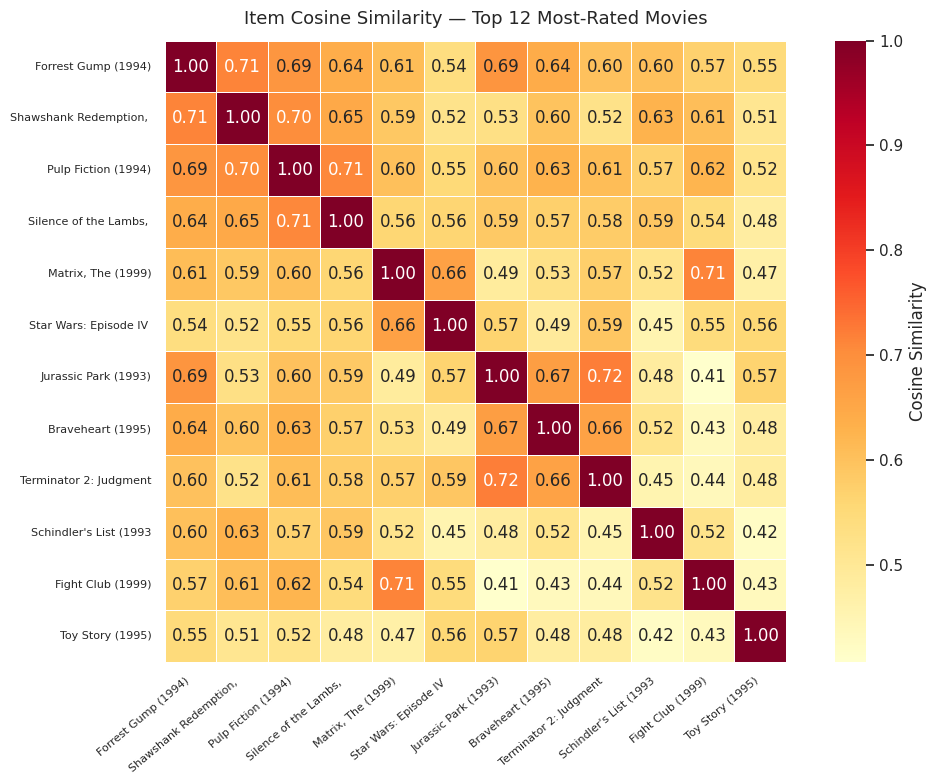

Heatmap saved.


In [15]:
# ── Cosine Similarity Heatmap — top-12 most-rated movies ─────────────────────
top12_ids = (
    ratings_filtered['movieId'].value_counts()
    .head(12).index.tolist()
)

# Short labels for readability
id_to_title = movies.set_index('movieId')['title'].to_dict()
short_labels = [id_to_title.get(m, str(m))[:22] for m in top12_ids]

sim_subset         = item_sim_df.loc[top12_ids, top12_ids].copy()
sim_subset.index   = short_labels
sim_subset.columns = short_labels

plt.figure(figsize=(11, 8))
sns.heatmap(
    sim_subset, annot=True, fmt='.2f',
    cmap='YlOrRd', linewidths=0.4, square=True,
    cbar_kws={'label': 'Cosine Similarity'}
)
plt.title('Item Cosine Similarity — Top 12 Most-Rated Movies', fontsize=13, pad=12)
plt.xticks(rotation=40, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()
print("Heatmap saved.")


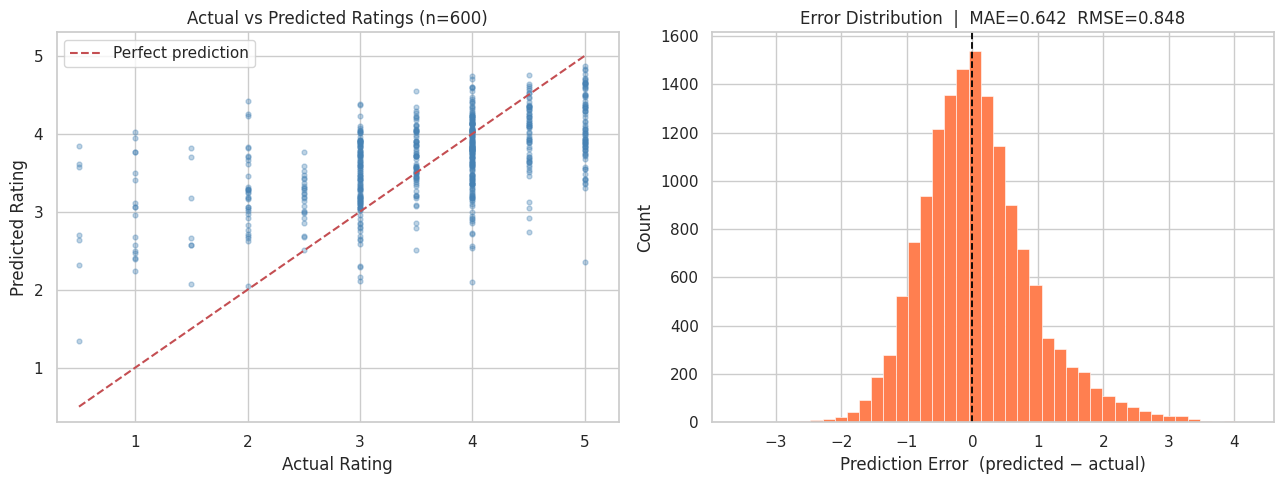

In [16]:
# ── Actual vs Predicted scatter + Error distribution ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Scatter — sample 600 points so the chart stays readable
sample_n = min(600, len(actuals))
idx = np.random.choice(len(actuals), sample_n, replace=False)
ax1.scatter(actuals[idx], predictions[idx],
            alpha=0.35, s=12, color='steelblue')
ax1.plot([0.5, 5], [0.5, 5], 'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel('Actual Rating')
ax1.set_ylabel('Predicted Rating')
ax1.set_title(f'Actual vs Predicted Ratings (n={sample_n})')
ax1.set_xlim(0.3, 5.3); ax1.set_ylim(0.3, 5.3)
ax1.legend()

# Error histogram
errors = predictions - actuals
ax2.hist(errors, bins=42, color='coral', edgecolor='white', linewidth=0.4)
ax2.axvline(0, color='black', linestyle='--', linewidth=1.3)
ax2.set_xlabel('Prediction Error  (predicted − actual)')
ax2.set_ylabel('Count')
ax2.set_title(f'Error Distribution  |  MAE={mae:.3f}  RMSE={rmse:.3f}')

plt.tight_layout()
plt.savefig('error_plots.png', dpi=130, bbox_inches='tight')
plt.show()


## 🆚 Section 10 (Bonus) — User-Based CF Comparison


In [17]:
# ── Build user-user cosine similarity on training data ────────────────────────
user_sim_values = cosine_similarity(train_filled)
user_sim_df     = pd.DataFrame(
    user_sim_values,
    index   = train_matrix.index,
    columns = train_matrix.index
)

FALLBACK_UB = train_data['rating'].mean()

def predict_user_based(user_id, movie_id, ui_matrix, u_sim_df,
                        top_k=20, fallback=FALLBACK_UB):
    """
    User-based CF prediction.
    Find the top-K most similar users who rated `movie_id`,
    then compute their similarity-weighted average rating.
    """
    if user_id not in u_sim_df.index or movie_id not in ui_matrix.columns:
        return fallback

    # Similarities to all other users, excluding self
    sims = u_sim_df.loc[user_id].drop(user_id, errors='ignore')

    # Keep only users who rated the target movie
    rated_by = ui_matrix[movie_id].dropna().index
    common   = sims.index.intersection(rated_by)

    if common.empty:
        return fallback

    sims_common = sims[common]
    sims_pos    = sims_common[sims_common > 0].nlargest(top_k)

    if sims_pos.empty:
        return fallback

    ratings_common = ui_matrix.loc[sims_pos.index, movie_id]
    denom = sims_pos.abs().sum()
    if denom == 0:
        return fallback

    return float(np.clip(
        np.dot(sims_pos.values, ratings_common.values) / denom, 0.5, 5.0
    ))


# ── Evaluate user-based CF on the same test set ───────────────────────────────
print("Evaluating User-Based CF … (may take ~60 seconds)")

act_ub, pred_ub = [], []
for row in test_data.itertuples(index=False):
    uid, mid, actual = row.userId, row.movieId, row.rating
    if uid not in train_matrix.index or mid not in train_matrix.columns:
        continue
    pred = predict_user_based(uid, mid, train_matrix, user_sim_df)
    act_ub.append(actual)
    pred_ub.append(pred)

act_ub  = np.array(act_ub)
pred_ub = np.array(pred_ub)

rmse_ub = sqrt(mean_squared_error(act_ub, pred_ub))
mae_ub  = float(np.mean(np.abs(act_ub - pred_ub)))

print()
print("╔════════════════════════════════════════════════╗")
print("║   ITEM-BASED CF   vs   USER-BASED CF          ║")
print("╠════════════════════════════════════════════════╣")
print(f"║  Item-Based  →  RMSE: {rmse:.4f}  |  MAE: {mae:.4f}  ║")
print(f"║  User-Based  →  RMSE: {rmse_ub:.4f}  |  MAE: {mae_ub:.4f}  ║")
print("╚════════════════════════════════════════════════╝")


Evaluating User-Based CF … (may take ~60 seconds)

╔════════════════════════════════════════════════╗
║   ITEM-BASED CF   vs   USER-BASED CF          ║
╠════════════════════════════════════════════════╣
║  Item-Based  →  RMSE: 0.8482  |  MAE: 0.6416  ║
║  User-Based  →  RMSE: 0.9246  |  MAE: 0.7176  ║
╚════════════════════════════════════════════════╝


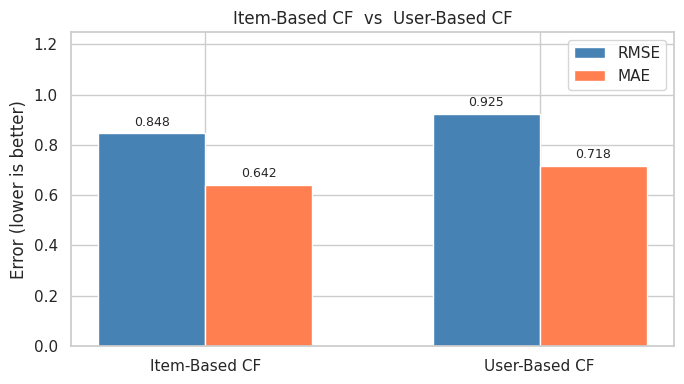

In [18]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
labels = ['Item-Based CF', 'User-Based CF']
rmse_vals = [rmse,    rmse_ub]
mae_vals  = [mae,     mae_ub]
x = np.arange(2)
w = 0.32

fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - w/2, rmse_vals, w, label='RMSE', color='steelblue')
b2 = ax.bar(x + w/2, mae_vals,  w, label='MAE',  color='coral')
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Error (lower is better)')
ax.set_title('Item-Based CF  vs  User-Based CF', fontsize=12)
ax.legend()
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
ax.set_ylim(0, max(rmse_vals + mae_vals) * 1.35)
plt.tight_layout()
plt.savefig('cf_comparison.png', dpi=130, bbox_inches='tight')
plt.show()


## 🖥️ Section 11 (Bonus) — Interactive Recommendation UI


In [19]:
# ── Widget definitions ────────────────────────────────────────────────────────
uid_input = widgets.BoundedIntText(
    value       = int(user_item_matrix.index[0]),
    min         = int(user_item_matrix.index.min()),
    max         = int(user_item_matrix.index.max()),
    step        = 1,
    description = 'User ID:',
    layout      = widgets.Layout(width='220px')
)
top_n_slider = widgets.IntSlider(
    value=10, min=3, max=20, step=1,
    description='Top-N:',
    layout=widgets.Layout(width='260px')
)
run_btn = widgets.Button(
    description  = '🎬  Get Recommendations',
    button_style = 'primary',
    layout       = widgets.Layout(width='210px', height='34px')
)
out = widgets.Output()

valid_uids = sorted(user_item_matrix.index.tolist())

def on_click(_):
    out.clear_output()
    with out:
        uid   = uid_input.value
        top_n = top_n_slider.value

        if uid not in valid_uids:
            display(HTML(
                f"<p style='color:red'>⚠️ User <b>{uid}</b> not in dataset. "
                f"Valid range: {valid_uids[0]} – {valid_uids[-1]}</p>"
            ))
            return

        recs    = recommend(uid, user_item_matrix, item_sim_df, movies, top_n=top_n)
        n_rated = int(user_item_matrix.loc[uid].notna().sum())

        # Build HTML table
        rows = ""
        for rank, r in enumerate(recs.itertuples(index=False), 1):
            bg    = '#f9f9f9' if rank % 2 == 0 else '#ffffff'
            stars = '⭐' * max(1, round(r.predicted_rating))
            rows += (
                f"<tr style='background:{bg}'>"
                f"<td style='padding:7px;text-align:center;font-weight:600'>{rank}</td>"
                f"<td style='padding:7px'>{r.title}</td>"
                f"<td style='padding:7px;text-align:center'>{r.predicted_rating:.2f}</td>"
                f"<td style='padding:7px;text-align:center'>{stars}</td>"
                "</tr>"
            )

        html = f"""
        <div style='font-family:Arial,sans-serif;max-width:680px;margin:8px 0'>
          <h3 style='color:#222;margin-bottom:4px'>
            🎬 Top-{top_n} Recommendations for User
            <span style='color:#c0392b'>{uid}</span>
          </h3>
          <p style='color:#555;font-size:13px'>
            Based on <b>{n_rated}</b> rated movies &nbsp;|&nbsp;
            Method: <em>Item-Based CF (cosine similarity)</em>
          </p>
          <table style='width:100%;border-collapse:collapse;
                        border:1px solid #ddd;font-size:14px'>
            <thead>
              <tr style='background:#2c3e50;color:#fff'>
                <th style='padding:9px'>#</th>
                <th style='padding:9px;text-align:left'>Movie Title</th>
                <th style='padding:9px'>Pred. Rating</th>
                <th style='padding:9px'>Stars</th>
              </tr>
            </thead>
            <tbody>{rows}</tbody>
          </table>
          <p style='color:#999;font-size:11px;margin-top:5px'>
            ℹ️ Scores are similarity-weighted averages of ratings
            the user gave to similar movies.
          </p>
        </div>
        """
        display(HTML(html))

run_btn.on_click(on_click)

display(widgets.HBox([uid_input, top_n_slider, run_btn]))
display(out)


Output()